#Exploring MYBPC3 Variants in ClinVar
## Objective
This project explores how variants in the MYBPC3 gene are classified in ClinVar, with particular attention to variants with uncertain or conflicting clinical interpretations.
## Data source
ClinVar

In [9]:
cd /Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/mybpc3_clinvar_analysis

/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/mybpc3_clinvar_analysis


/Users/apple/Library/Python/3.9/lib/python/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [15]:
from pathlib import Path 
import pandas as pd
import matplotlib.pyplot as plt 

In [ ]:
data_raw=pd.read_csv('rawdata/clinvar_download_20260804_102412.tsv', sep='\t', header=0)
data_raw.shape
data_raw.head()
data_raw.columns.tolist()
data_raw.Genes.value_counts()
data_raw.info()

In [219]:
quality_summary=pd.DataFrame({'Columns': data_raw.columns, 'Data_type': [str(data_raw[col].dtypes) for col in data_raw.columns], 'Missing_count': [data_raw[col].isna().sum() for col in data_raw.columns]})
quality_summary['Missing_percentage']=(quality_summary.Missing_count/len(data_raw)*100).round(2)
quality_summary
quality_summary.to_csv('result/data_quality_summary.csv', index=False)

In [220]:
data_raw.Classification.value_counts()
data_raw.Classification_cleaned=data_raw.Classification.fillna('Missing').str.replace(r'G:\s*','',regex=True).str.strip()
data_raw.Classification_cleaned.value_counts(dropna=False)

/var/folders/gl/p_qbjr5514g5k40d1fx20ck40000gn/T/ipykernel_25407/1468071435.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_raw.Classification_cleaned=data_raw.Classification.fillna('Missing').str.replace(r'G:\s*','',regex=True).str.strip()


Classification
Uncertain significance                          1904
Likely benign                                   1121
Pathogenic                                       671
Conflicting classifications of pathogenicity     399
Likely pathogenic                                218
Pathogenic/Likely pathogenic                     172
Benign/Likely benign                             100
Benign                                            76
Missing                                            2
not provided                                       2
risk factor                                        1
Name: count, dtype: int64

In [101]:
classification_map={'Pathogenic': 'Pathogenic / likely pathogenic', 'Likely pathogenic': 'Pathogenic / likely pathogenic', 'Pathogenic/Likely pathogenic': 'Pathogenic / likely pathogenic',
"Benign": "Benign / likely benign", "Likely benign": "Benign / likely benign", "Benign/Likely benign": "Benign / likely benign", "Uncertain significance": "Uncertain significance",   "Conflicting classifications of pathogenicity": "Conflicting classifications", "risk factor": "Other / not provided", "not provided": "Other / not provided","Missing": "Other / not provided"}

In [221]:
data_raw['Classification_group']=data_raw.Classification_cleaned.map(classification_map)
data_raw['Classification_group'].isna().sum()
group_count=(data_raw['Classification_group'].value_counts().reset_index())
group_count.columns=['Classification_group', 'Count']
group_count['Percentage'] = (group_count.Count/ group_count.Count.sum()* 100).round(1)
group_count

,Classification_group,Count,Percentage
0,Uncertain significance,1904,40.8
1,Benign / likely benign,1297,27.8
2,Pathogenic / likely pathogenic,1061,22.7
3,Conflicting classifications,399,8.6
4,Other / not provided,5,0.1


# overview computing

In [222]:
classification_order=['Uncertain significance', 'Benign / likely benign', 'Pathogenic / likely pathogenic', 'Conflicting classifications', 'Other / not provided']

In [223]:
classification_summary=data_raw.Classification_group.value_counts().reindex(classification_order).reset_index() 
classification_summary.columns=['Classification_group', 'Count']
classification_summary.Count = (pd.to_numeric(classification_summary.Count, errors="coerce").fillna(0).astype(int))
classification_summary['Percentage']=(classification_summary.Count/classification_summary.Count.sum()*100).round(1)
classification_summary
classification_summary.to_csv('result/classification_summary.csv', index=False)

# clinical classificaiton distribution

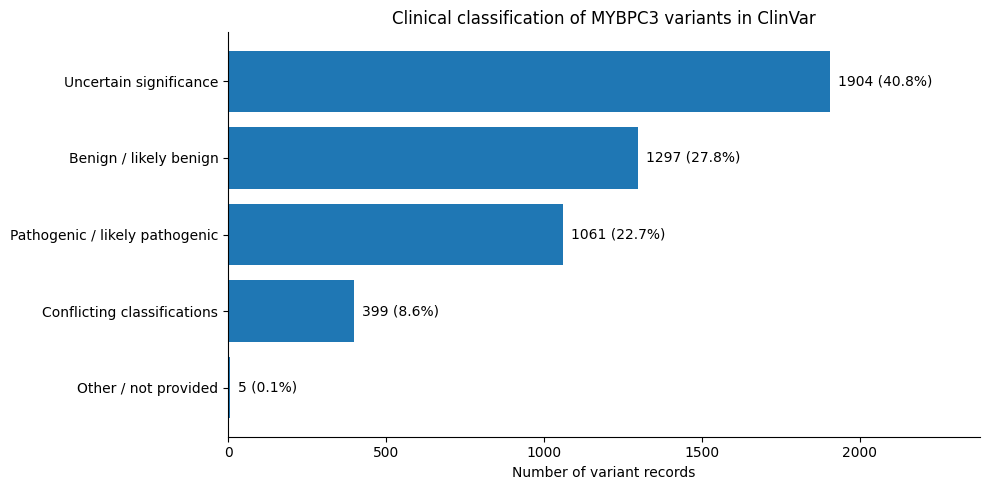

In [224]:
fig, ax=plt.subplots(figsize=(10,5))
bars=ax.barh(classification_summary.Classification_group, classification_summary.Count)
ax.invert_yaxis()
ax.set_title('Clinical classification of MYBPC3 variants in ClinVar')
ax.set_xlabel('Number of variant records')
ax.set_ylabel('')
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
for bar, count, percentage in zip(bars, classification_summary.Count, classification_summary.Percentage):
    ax.text(x=bar.get_width() + 25, 
            y=bar.get_y() + bar.get_height()/2,
            s=f'{count:} ({percentage:.1f}%)',
            va='center')
ax.set_xlim(0, classification_summary.Count.max()*1.25)
plt.tight_layout()
plt.show()
fig.savefig('figure/01_classification_distribution.png')

# review status analysis 

In [225]:
data_raw.head()
data_raw['Review status'].value_counts(dropna=False)
data_raw['Review status_cleaned']=data_raw['Review status'].fillna('Missing').str.strip().str.lower()
review_map={'reviewed by expert panel': 'Expert panel', 'criteria provided, multiple submitters, no conflicts': 'Multiple submitters, not conflicted', 'criteria provided, single submitter': 'Single submitter', 'criteria provided, conflicting classifications': 'Conflicting submissions', 'no assertion criteria provided': 'No assertation criteria', 'no classification provided': 'Missing', 'missing': 'Missing'}
data_raw['Review_status_group']=data_raw['Review status_cleaned'].map(review_map)
data_raw.loc[data_raw["Review_status_group"].isna(),"Review status_cleaned"].value_counts()

Series([], Name: count, dtype: int64)

In [226]:
review_summary=data_raw.Review_status_group.value_counts().reset_index()
review_summary.columns=['Review_status_group', 'Count']
review_summary['Percentage']=(review_summary.Count / review_summary.Count.sum() * 100).round(1)
review_summary.to_csv('result/review_summary.csv', index=False)

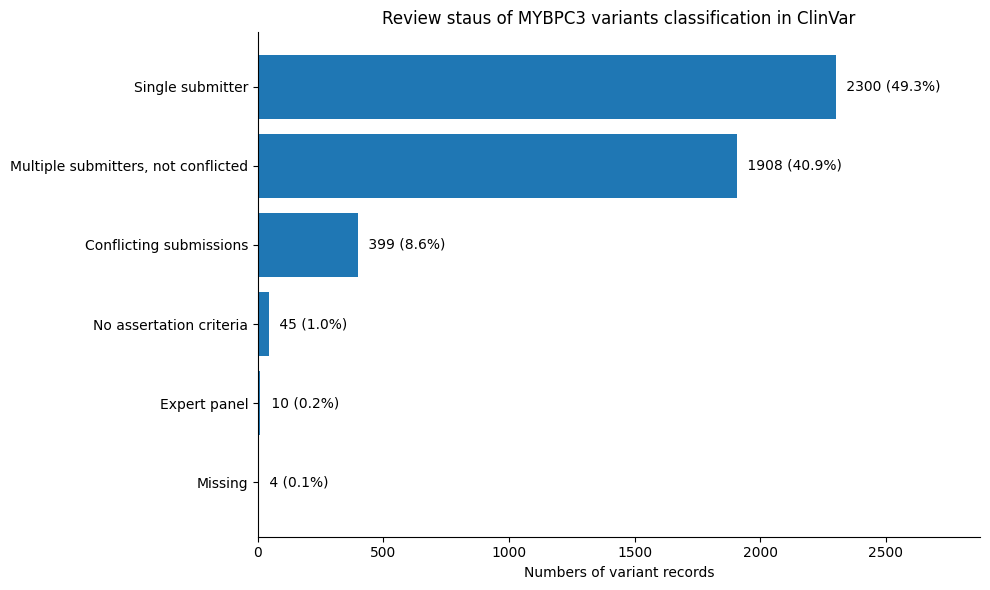

In [227]:
fig, ax=plt.subplots(figsize=(10,6))
bars=ax.barh(review_summary.Review_status_group, review_summary.Count)
ax.invert_yaxis()
ax.set_title('Review staus of MYBPC3 variants classification in ClinVar')
ax.set_xlabel('Numbers of variant records')
ax.set_ylabel('')
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
for bar, count, percentage in zip(bars, review_summary.Count, review_summary.Percentage):
    ax.text(x=bar.get_width()+25,
    y=bar.get_y() + bar.get_height()/2,
    s=f'{count: } ({percentage:.1f}%)',
    va='center')
ax.set_xlim(0, review_summary.Count.max()*1.25) 
plt.tight_layout()
plt.show()
fig.savefig('figure/02_review_status_distirbution.png')

# relationship between classification and review status

In [228]:
classification_review_counts=pd.crosstab(data_raw.Classification_group, data_raw.Review_status_group)
classification_review_pct=(pd.crosstab(data_raw.Classification_group, data_raw.Review_status_group, normalize='index')*100).round(1) 
classification_review_pct
classification_review_pct.sum(axis=1)


Classification_group
Benign / likely benign            100.0
Conflicting classifications       100.0
Other / not provided              100.0
Pathogenic / likely pathogenic    100.0
Uncertain significance            100.0
dtype: float64

In [229]:
preferred_review_order = ["Expert panel", "Multiple submitters, no conflicts", "Single submitter", "Conflicting submissions", "No assertion criteria", "Limited / no criteria", "Missing / no classification"]
review_order = ["Expert panel", "Multiple submitters, no conflicts", "Single submitter", "Conflicting submissions",  "No assertion criteria", "Limited / no criteria","Missing / no classification"]
review_order=[category for category in preferred_review_order if category in classification_review_pct.columns] 
review_order +=[category for category in classification_review_pct.columns if category not in review_order] 
classification_review_pct=(classification_review_pct.reindex(index=classification_order, columns=review_order).fillna(0))
classification_review_counts.to_csv("result/classification_by_review_status_counts.csv")
classification_review_pct.to_csv("result/classification_by_review_status_percent.csv")


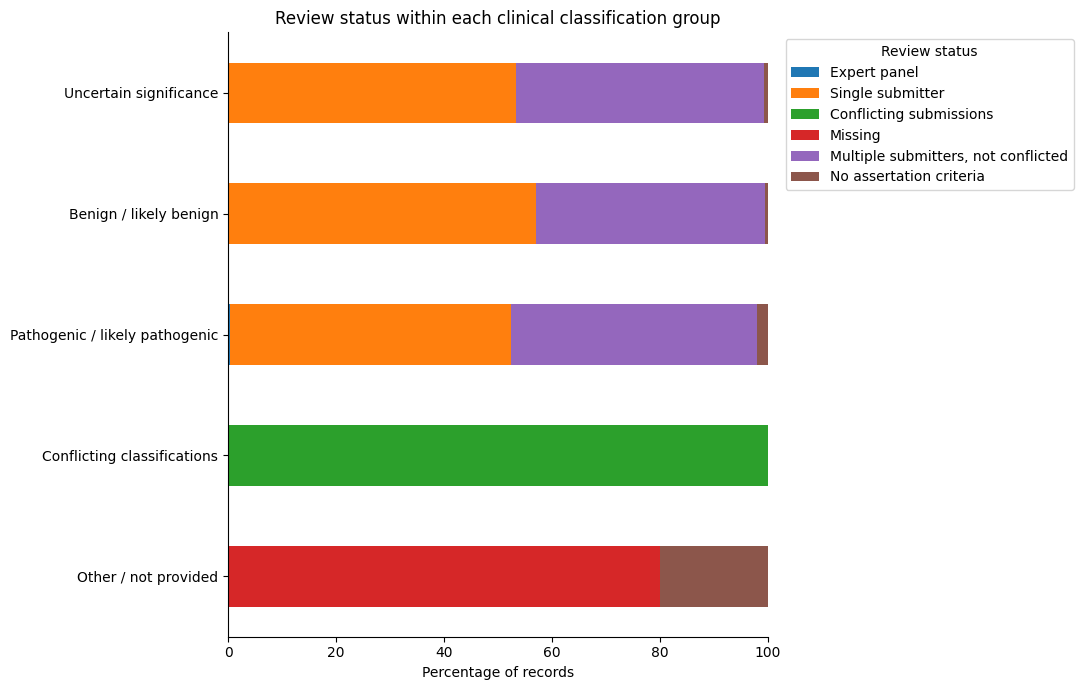

In [230]:
fig, ax=plt.subplots(figsize=(11,7))
classification_review_pct.plot(kind='barh', stacked=True, ax=ax) 
ax.invert_yaxis()
ax.set_title('Review status within each clinical classification group')
ax.set_xlabel("Percentage of records")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Review status",bbox_to_anchor=(1.02, 1),loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
fig.savefig("figure/03_classification_by_review_status.png",dpi=300, bbox_inches="tight")


# variant type

In [231]:
data_raw.Type.value_counts()
variant_type_map = {"single nucleotide variant": "Single nucleotide variant", "Deletion": "Deletion", "Duplication": "Duplication", "Indel": "Indel", "Insertion": "Insertion", "Microsatellite": "Microsatellite", "Inversion": "Inversion"}
data_raw['Variant_type_group']=data_raw.Type.map(variant_type_map).fillna('Other')
variant_type_summary = (data_raw["Variant_type_group"].value_counts().reset_index())
variant_type_summary.columns=['Variant_type_group', 'Count']
variant_type_summary['Percentage']=(variant_type_summary.Count/ variant_type_summary.Count.sum()*100).round(1)
variant_type_summary
variant_type_summary.to_csv('result/variant_type_summary.csv', index=False)

# molecular consequence analysis

In [232]:
data_raw['Molecular consequence'].value_counts()
molecular_long = (data_raw.assign(Molecular_consequence_item=(data_raw["Molecular consequence"].fillna("Missing").str.split(r",\s*"))).explode("Molecular_consequence_item"))
molecular_long["Molecular_consequence_item"] = (molecular_long["Molecular_consequence_item"].str.strip())
def classify_molecular_consequence(value):
    value = str(value).strip().lower()
    if value in [
        "frameshift variant",
        "nonsense"
    ]:
        return "Protein-truncating"
    if "splice" in value:
        return "Splice-related"
    if value in [
        "missense variant",
        "initiator_codon_variant",
        "stop lost",
        "inframe_deletion",
        "inframe_insertion",
        "inframe_indel"
    ]:
        return "Protein-changing"
    if value == "synonymous variant":
        return "Synonymous"
    if value in [
        "intron variant",
        "3 prime utr variant",
        "5 prime utr variant"
    ]:
        return "Intronic / non-coding"
    if value == "missing":
        return "Missing"
    return "Other"


In [233]:
data_raw["Molecular consequence"].isna().sum()

np.int64(160)

In [234]:
molecular_long["Molecular_consequence_group"] = molecular_long["Molecular_consequence_item"].apply(classify_molecular_consequence)

In [235]:
molecular_summary = (molecular_long["Molecular_consequence_group"].value_counts().reset_index())
molecular_summary.columns = ["Molecular_consequence_group","Count"]
molecular_summary["Percentage"] = (molecular_summary["Count"]/ molecular_summary["Count"].sum()* 100).round(1)
molecular_summary
molecular_summary.to_csv("result/molecular_consequence_summary.csv",index=False)

# 筛选未解决的变异

In [236]:
unresolved_variants = data_raw[data_raw['Classification_group'].isin(['Uncertain significance', 'Conflicting classifications'])].copy().copy()
print("Number of unresolved records:", len(unresolved_variants))
unresolved_percentage = (len(unresolved_variants) / len(data_raw)* 100)
print(f"Percentage unresolved: {unresolved_percentage:.1f}%")

Number of unresolved records: 2303
Percentage unresolved: 49.4%


# 分析未解决变异的分子后果

In [237]:
unresolved_molecular_long = (unresolved_variants.assign(Molecular_consequence_item=(
unresolved_variants["Molecular consequence"].fillna("Missing").str.split(r",\s*")))
.explode("Molecular_consequence_item"))
unresolved_molecular_long["Molecular_consequence_item"] = (
unresolved_molecular_long["Molecular_consequence_item"].str.strip())
unresolved_molecular_long["Molecular_consequence_group"] = (
unresolved_molecular_long["Molecular_consequence_item"].apply(classify_molecular_consequence))

In [ ]:
unresolved_molecular_summary = (unresolved_molecular_long['Molecular_consequence_group'].value_counts().reset_index())
unresolved_molecular_summary.columns = ["Molecular_consequence_group", "Count"]
unresolved_molecular_summary["Percentage"] = (unresolved_molecular_summary["Count"] / unresolved_molecular_summary["Count"].sum()* 100).round(1)
unresolved_molecular_summary

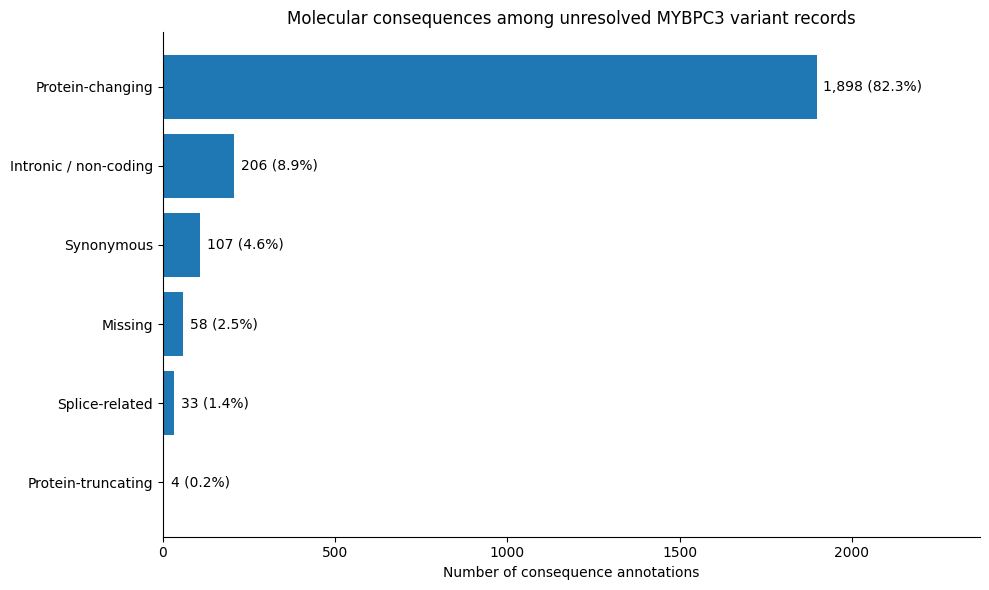

In [241]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(unresolved_molecular_summary["Molecular_consequence_group"],unresolved_molecular_summary["Count"])
ax.invert_yaxis()
ax.set_title("Molecular consequences among unresolved MYBPC3 variant records")
ax.set_xlabel("Number of consequence annotations")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, count, percentage in zip(
    bars,
    unresolved_molecular_summary["Count"],
    unresolved_molecular_summary["Percentage"]):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.1f}%)",
        va="center"
    )
ax.set_xlim(0,unresolved_molecular_summary["Count"].max() * 1.25)
plt.tight_layout()
plt.show()
fig.savefig('figure/04_unresolved_molecular_consequences.png', dpi=300, bbox_inches="tight")

# 找出剪接相关的未解决记录

In [ ]:
splice_related_unresolved = unresolved_variants[unresolved_variants["Molecular consequence"].fillna("").str.contains("splice",case=False,regex=False)].copy()
print("Unresolved splice-related records:",len(splice_related_unresolved))
splice_related_unresolved["Classification_group"].value_counts()
splice_related_unresolved["Review_status_group"].value_counts()


In [247]:
unresolved_molecular_summary.to_csv("result/unresolved_molecular_consequence_summary.csv", index=False)
unresolved_variants.to_csv('result/mybpc3_unresolved_variants.csv',index=False)
splice_related_unresolved.to_csv('result/unresolved_splice_related_variants.csv',index=False)
data_raw.to_csv('result/clinvar_mybpc3_cleaned.csv',index=False)

In [127]:
data_raw.head()


,Variation,Genes,Type,Condition,Classification,Review status,Molecular consequence,Protein change,Germline date last evaluated,Somatic clinical impact date last evaluated,Oncogenicity date last evaluated,GRCh37 Location,GRCh38 Location,Variation ID,VCV accession,rs_ID,Review status_cleaned
0,NC_000011.10:g.47331206C>T,MYBPC3,single nucleotide variant,not provided,G: Benign,"criteria provided, single submitter",NaN,NaN,2015/03/03,NaN,NaN,11:47352757,11:47331206,1233585,VCV001233585,rs3729805,"criteria provided, single submitter"
1,NC_000011.10:g.47331311G>A,MYBPC3,single nucleotide variant,not provided,G: Benign,"criteria provided, multiple submitters, no con...",NaN,NaN,2015/03/03,NaN,NaN,11:47352862,11:47331311,1253549,VCV001253549,rs3729804,"criteria provided, multiple submitters, no con..."
2,NC_000011.10:g.47331331A>T,MYBPC3,single nucleotide variant,not provided,G: Benign,"criteria provided, single submitter",NaN,NaN,2015/03/03,NaN,NaN,11:47352882,11:47331331,1271781,VCV001271781,rs576187732,"criteria provided, single submitter"
3,NM_000256.3(MYBPC3):c.*314A>G,MYBPC3,single nucleotide variant,not provided,G: Benign,"criteria provided, single submitter",3 prime UTR variant,NaN,2015/03/03,NaN,NaN,11:47352980,11:47331429,1258006,VCV001258006,rs975731675,"criteria provided, single submitter"
4,NM_000256.3(MYBPC3):c.*294T>A,MYBPC3,single nucleotide variant,not provided,G: Benign,"criteria provided, single submitter",3 prime UTR variant,NaN,2015/03/03,NaN,NaN,11:47353000,11:47331449,1262135,VCV001262135,rs939074534,"criteria provided, single submitter"
